# Проект второго модуля. Исследование стартапов

## Введение

В данном проекте используются данные о стартапах, содержащие информацию о компаниях, их деятельности, объёмах привлечённого финансирования, количестве инвестиционных раундов, географии, а также датах основания и финансирования.

Цель работы - провести исследовательский анализ данных о стартапах, выполнить их предобработку, изучить особенности финансирования компаний и определить наиболее перспективные направления для инвестирования.

В ходе проекта будут загружены и подготовлены данные, обработаны пропущенные значения и дубликаты, созданы дополнительные признаки, исследованы аномальные значения и проанализирована динамика финансирования. По результатам анализа будут сформулированы выводы и рекомендации для потенциального инвестора.

## Шаг 1. Знакомство с данными: загрузка и предобработка

Датасет получен из базы данных стартапов.

Название основного датасета — `cb_investments.zip`. Внутри архива один файл — `cb_investments.csv`.

Описание данных:
* `name` — название компании.
* `homepage_url` — ссылка на сайт компании.
* `category_list` — категории, в которых работает компания. Указываются через `|`.
* `market` — основной рынок или отрасль компании.
* `funding_total_usd` — общий объём привлечённых инвестиций в долларах США.
* `status` — текущий статус компании, например `operating`, `closed` и так далее.
* `country_code` — код страны, например USA.
* `state_code` — код штата или региона, например, CA.
* `region` — регион, например, SF Bay Area.
* `city` — город, в котором расположена компания.
* `funding_rounds` — общее число раундов финансирования.
* `participants` — число участников в раундах финансирования.
* `founded_at` — дата основания компании.
* `founded_month` — месяц основания в формате `YYYY-MM`.
* `founded_quarter` — квартал основания в формате `YYYY-QN`.
* `founded_year` — год основания.
* `first_funding_at` — дата первого финансирования.
* `mid_funding_at` — дата среднего по времени раунда финансирования.
* `last_funding_at` — дата последнего финансирования.
* `seed` — сумма инвестиций на посевной стадии.
* `venture` — сумма венчурных инвестиций.
* `equity_crowdfunding` — сумма, привлечённая через долевой краудфандинг.
* `undisclosed` — сумма финансирования нераскрытого типа.
* `convertible_note` — сумма инвестиций через конвертируемые займы.
* `debt_financing` — сумма долгового финансирования.
* `angel` — сумма инвестиций от бизнес-ангелов.
* `grant` — сумма полученных грантов.
* `private_equity` — сумма инвестиций в виде прямых (частных) вложений.
* `post_ipo_equity` — сумма финансирования после IPO.
* `post_ipo_debt` — сумма долгового финансирования после IPO.
* `secondary_market` — сумма сделок на вторичном рынке.
* `product_crowdfunding` — сумма, привлечённая через продуктовый краудфандинг.
* `round_A` — `round_H` — сумма инвестиций в соответствующем раунде.

Название дополнительного датасета — `cb_returns.csv`. Он содержит суммы возвратов по типам финансирования в миллионах долларов по годам.

Описание данных:
* `year` — год возврата средств.
* `seed` — сумма возвратов от посевных инвестиций.
* `venture` — сумма возвратов от венчурных инвестиций.
* `equity_crowdfunding` — сумма, возвращённая по долевому краудфандингу.
* `undisclosed` — сумма возвратов нераскрытого типа.
* `convertible_note` — сумма возвратов через конвертируемые займы.
* `debt_financing` — сумма возвратов от долгового финансирования.
* `angel` — сумма возвратов бизнес-ангелам.
* `grant` — сумма возвратов по грантам.
* `private_equity` — сумма возвратов прямых (частных) вложений.
* `post_ipo_equity` — сумма возвратов от IPO.
* `post_ipo_debt` — сумма возвратов от долгового IPO.
* `secondary_market` — сумма возвратов от сделок на вторичном рынке.
* `product_crowdfunding` — сумма возвратов по продуктовому краудфандингу.

Файлы находятся в папке `datasets`, если вы выполняете работу на платформе. В случае, если вы делаете работу локально, доступ к файлам в папке можно получить по адресу `https://code.s3.yandex.net/datasets/` + имя файла.

### 1.1. Вывод общей информации

На первом этапе исследования необходимо загрузить данные и ознакомиться с их структурой. Для этого загрузим необходимые библиотеки и данные из двух датасетов: `cb_investments.csv` и `cb_returns.csv`.

In [1]:
# Импортируем библиотеки
import pandas as pd
import numpy as np

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Выгружаем данные в переменные investments_df и returns_df
investments_df = pd.read_csv('.../datasets/cb_investments.zip', sep=';', low_memory=False)

returns_df = pd.read_csv('.../datasets/cb_returns.csv')

Для начала выведем первые строки каждого датафрейма с помощью метода `head()`, чтобы познакомиться со структурой данных. Затем воспользуемся методом `info()`, который позволит оценить типы данных, количество заполненных значений и обнаружить возможные проблемы, требующие обработки на этапе предобработки.

In [3]:
# Выведем первые строки основного датасета
investments_df.head()

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,Harvard University,http://harvard.edu,|Education|,Education,"9,00,00,000",operating,USA,MA,Boston,Cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,University of New Brunswick,http://www.unb.ca,NaN,NaN,"20,00,000",operating,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,"90,00,000",operating,USA,DE,"Wilmington, Delaware",Wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,University of Michigan,http://www.umich.edu/,|Education|,Education,"77,00,000",operating,USA,MI,Detroit,Ann Arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,"5,40,000",operating,USA,OH,Cleveland,Cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
# Выводим информацию о датафрейме investments_df
investments_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  object 
 1   homepage_url          45989 non-null  object 
 2   category_list         45477 non-null  object 
 3    market               45477 non-null  object 
 4    funding_total_usd    49438 non-null  object 
 5   status                48124 non-null  object 
 6   country_code          44165 non-null  object 
 7   state_code            30161 non-null  object 
 8   region                44165 non-null  object 
 9   city                  43322 non-null  object 
 10  funding_rounds        49438 non-null  float64
 11  participants          30473 non-null  float64
 12  founded_at            38554 non-null  object 
 13  founded_month         38482 non-null  object 
 14  founded_quarter       38482 non-null  object 
 15  founded_year       

Датафрейм `investments_df` содержит 40 столбцов и 54 294 строки, в которых представлена информация о стартапах, их деятельности, местоположении, статусе, финансировании и различных типах инвестиций.

После первичного анализа данных можно сделать следующие выводы:
- Названия столбцов на первый взгляд оформлены в едином стиле, однако перед дальнейшей работой необходимо отдельно проверить их на наличие лишних пробелов и других скрытых символов
- В датафрейме используются типы данных `object` и `float64`. При этом часть столбцов с датами (`founded_at`, `first_funding_at`, `mid_funding_at`, `last_funding_at`) хранится в формате `object` и требует преобразования в тип `datetime`.
- Столбец `funding_total_usd`, содержащий общий объём привлечённого финансирования, также имеет тип `object`. Перед анализом необходимо привести его к числовому типу данных
- В данных присутствуют пропущенные значения. Они встречаются как в текстовых признаках, так и в столбцах с датами и информацией о финансировании. На следующем этапе необходимо определить причины их появления и выбрать способ обработки
- Судя по первому знакомству с данными, значения столбцов соответствуют их описанию, однако дополнительно следует проверить данные на наличие явных и неявных дубликатов

Теперь познакомимся с данными датасета `cb_returns.csv`.

In [5]:
# Выведем первые строки датасета с данными о возвратах
returns_df.head()

,year,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
0,2000,16.70,55.40,0.0,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.0,0.20,0.0
1,2001,2.88,23.49,0.0,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.0,0.46,0.0
2,2002,6.59,209.42,0.0,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.0,0.06,0.0
3,2003,7.74,233.86,0.0,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.0,0.08,0.0
4,2004,9.93,555.90,0.0,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.0,0.55,0.0


In [6]:
# Выведем общую информацию о датасете с данными о возвратах
returns_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  15 non-null     int64  
 1   seed                  15 non-null     float64
 2   venture               15 non-null     float64
 3   equity_crowdfunding   15 non-null     float64
 4   undisclosed           15 non-null     float64
 5   convertible_note      15 non-null     float64
 6   debt_financing        15 non-null     float64
 7   angel                 15 non-null     float64
 8   grant                 15 non-null     float64
 9   private_equity        15 non-null     float64
 10  post_ipo_equity       15 non-null     float64
 11  post_ipo_debt         15 non-null     float64
 12  secondary_market      15 non-null     float64
 13  product_crowdfunding  15 non-null     float64
dtypes: float64(13), int64(1)
memory usage: 1.8 KB


Датафрейм `returns_df` содержит 15 строк и 14 столбцов, в которых представлена информация о возврате средств по различным типам финансирования за период с 2000 по 2014 год.

После первичного анализа данных можно сделать следующие выводы:
- Названия столбцов соответствуют единому стилю и не требуют дополнительного преобразования
- Все признаки имеют корректные типы данных: столбец `year` хранится в формате `int64`, остальные столбцы - в формате `float64`, что соответствует представленным в них значениям
- Пропущенные значения в датафрейме отсутствуют, поэтому дополнительная обработка пропусков не потребуется
- Судя по первому знакомству с данными, значения столбцов соответствуют их описанию. Данный датафрейм выглядит подготовленным к дальнейшему анализу и может быть использован без существенной предобработки

По результатам первичного знакомства можно сделать вывод, что данные в целом соответствуют описанию проекта и подходят для дальнейшего анализа. При этом в основном датафрейме присутствуют пропущенные значения, а часть признаков требует изменения типа данных. Дополнительный датафрейм, напротив, выглядит полностью подготовленным к работе.

Следующим этапом исследования станет предобработка данных, которая позволит устранить выявленные особенности и подготовить датасеты к дальнейшему анализу.

### 1.2. Предобработка данных

Перед началом предобработки проверим названия столбцов в обоих датафреймах. Это позволит убедиться, что они оформлены в едином стиле, не содержат лишних символов и не потребуют переименования перед дальнейшим анализом.

In [7]:
# Выведем названия столбцов основного датафрейма
investments_df.columns

Index(['name', 'homepage_url', 'category_list', ' market ',
       ' funding_total_usd ', 'status', 'country_code', 'state_code', 'region',
       'city', 'funding_rounds', 'participants', 'founded_at', 'founded_month',
       'founded_quarter', 'founded_year', 'first_funding_at', 'mid_funding_at',
       'last_funding_at', 'seed', 'venture', 'equity_crowdfunding',
       'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding', 'round_A', 'round_B',
       'round_C', 'round_D', 'round_E', 'round_F', 'round_G', 'round_H'],
      dtype='object')

In [8]:
# Выведем названия столбцов датафрейма с данными о возвратах
returns_df.columns

Index(['year', 'seed', 'venture', 'equity_crowdfunding', 'undisclosed',
       'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding'],
      dtype='object')

In [9]:
# Уберем лишние пробелы в названиях столбцов основного датафрейма
investments_df.columns = investments_df.columns.str.strip()

# Уберем лишние пробелы в названиях столбцов датафрейма с возвратами
returns_df.columns = returns_df.columns.str.strip()

# Проверим результат
investments_df.columns

Index(['name', 'homepage_url', 'category_list', 'market', 'funding_total_usd',
       'status', 'country_code', 'state_code', 'region', 'city',
       'funding_rounds', 'participants', 'founded_at', 'founded_month',
       'founded_quarter', 'founded_year', 'first_funding_at', 'mid_funding_at',
       'last_funding_at', 'seed', 'venture', 'equity_crowdfunding',
       'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding', 'round_A', 'round_B',
       'round_C', 'round_D', 'round_E', 'round_F', 'round_G', 'round_H'],
      dtype='object')

В названиях столбцов основного датафрейма были обнаружены лишние пробелы у признаков `market` и `funding_total_usd`. Эти пробелы могли мешать обращению к столбцам по названию, поэтому они были удалены.

В датафрейме `returns_df` названия столбцов уже были оформлены корректно. После обработки названия столбцов в обоих датафреймах приведены к единому виду.

Дополнительное переименование столбцов не требуется, поэтому можно переходить к следующим этапам предобработки.

На этапе первичного знакомства было выявлено, что столбец `funding_total_usd` имеет тип `object`, хотя содержит данные об общем объёме привлечённого финансирования. Это связано с тем, что в значениях используется разделитель разрядов. Для дальнейших расчётов необходимо убрать запятые и привести столбец к числовому типу данных.

При попытке преобразовать столбец `funding_total_usd` к числовому типу была обнаружена ещё одна особенность данных: кроме разделителей разрядов, в столбце встречается значение `" - "`. Такое значение фактически обозначает отсутствие информации о сумме финансирования, поэтому перед преобразованием его нужно заменить на пропуск.

In [10]:
# Убираем запятые, которые используются как разделители разрядов
investments_df['funding_total_usd'] = investments_df['funding_total_usd'].str.replace(',', '')

# Заменим значения с дефисом на пропуски
investments_df['funding_total_usd'] = investments_df['funding_total_usd'].replace(r'^\s*-\s*$', pd.NA, regex=True)

# Преобразуем столбец funding_total_usd в числовой тип данных
investments_df['funding_total_usd'] = pd.to_numeric(investments_df['funding_total_usd'])

# Проверяем результат преобразования
investments_df['funding_total_usd'].dtype

dtype('float64')

Столбец `funding_total_usd` был очищен от разделителей разрядов и значений-индикаторов отсутствия данных. После этого признак удалось привести к числовому типу данных. Теперь его можно использовать для дальнейших расчётов и анализа объёма привлечённого финансирования.

Следующим этапом приведём столбцы с датами к типу `datetime`. Это позволит выполнять операции с датами, рассчитывать временные интервалы и анализировать динамику финансирования компаний.

In [11]:
# Сохраним названия столбцов с датами в список
date_columns = ['founded_at',
    'first_funding_at',
    'mid_funding_at',
    'last_funding_at']

# Выведем первые строки столбцов с датами
investments_df[date_columns].head()

,founded_at,first_funding_at,mid_funding_at,last_funding_at
0,1636-09-08,2014-01-06,NaN,2014-01-06
1,1785-01-01,2014-05-15,NaN,2014-05-15
2,1802-07-19,2009-07-02,2009-07-02,2009-07-02
3,1817-01-01,2013-11-21,2013-11-21,2014-11-03
4,1826-01-01,2014-01-14,NaN,2014-01-14


По первым строкам видно, что даты записаны в формате `YYYY-MM-DD`, однако столбцы имеют строковый тип данных. Такой формат записи позволяет без дополнительных преобразований привести признаки к типу `datetime`. При преобразовании используем параметр `errors='coerce'`, чтобы возможные некорректные значения автоматически заменялись на `NaT` и не приводили к ошибкам.

In [12]:
# Преобразуем столбцы с датами к типу datetime. Некорректные значения автоматически заменятся на NaT
for column in date_columns:
    investments_df[column] = pd.to_datetime(investments_df[column], errors='coerce')

# Проверим результат преобразования
investments_df[date_columns].dtypes

founded_at          datetime64[ns]
first_funding_at    datetime64[ns]
mid_funding_at      datetime64[ns]
last_funding_at     datetime64[ns]
dtype: object

Столбцы с датами были приведены к типу `datetime64`. Теперь их можно использовать для дальнейшего анализа временных промежутков и динамики финансирования стартапов.

В датафрейме `returns_df` столбец `year` содержит год, к которому относятся данные о возвратах по типам финансирования. Так как каждая строка соответствует отдельному году, сделаем этот столбец индексом датафрейма.

In [13]:
# Сделаем столбец year индексом датафрейма returns_df
returns_df = returns_df.set_index('year')

# Проверим результат
returns_df.head()

,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
year,,,,,,,,,,,,,
2000,16.70,55.40,0.0,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.0,0.20,0.0
2001,2.88,23.49,0.0,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.0,0.46,0.0
2002,6.59,209.42,0.0,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.0,0.06,0.0
2003,7.74,233.86,0.0,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.0,0.08,0.0
2004,9.93,555.90,0.0,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.0,0.55,0.0


Теперь проверим данные на наличие пропусков. Узнаем абсолютное и относительное количество пропусков в этом столбце.

In [14]:
# Посчитаем количество и долю пропусков
missing_df = pd.DataFrame({
    'Количество пропусков': investments_df.isna().sum(),
    'Доля пропусков (%)': (investments_df.isna().mean() * 100).round(2)
})

# Оставим только столбцы с пропусками
missing_df = missing_df.query('`Количество пропусков` > 0')

missing_df.sort_values(by='Количество пропусков', ascending=False)

,Количество пропусков,Доля пропусков (%)
state_code,24133,44.45
mid_funding_at,24006,44.21
participants,23821,43.87
founded_quarter,15812,29.12
founded_month,15812,29.12
founded_at,15741,28.99
founded_year,15740,28.99
funding_total_usd,13387,24.66
city,10972,20.21
region,10129,18.66


In [15]:
# Посчитаем количество и долю пропусков в датафрейме с возвратами
missing_returns = pd.DataFrame({
    'Количество пропусков': returns_df.isna().sum(),
    'Доля пропусков (%)': (returns_df.isna().mean() * 100).round(2)
})

# Оставим только столбцы с пропусками
missing_returns = missing_returns.query('`Количество пропусков` > 0')

# Выведем результат
missing_returns.sort_values(by='Количество пропусков', ascending=False)

,Количество пропусков,Доля пропусков (%)


В датафрейме `investments_df` пропуски встречаются в большом количестве столбцов. Наибольшая доля пропущенных значений наблюдается в `state_code`, `mid_funding_at` и `participants` - более 40%. Также пропуски есть в столбцах, связанных с датой основания компании, географией, рынком и общим объёмом финансирования.

Пропуски в географических признаках (`state_code`, `city`, `region`, `country_code`) могут быть связаны с тем, что информация о местоположении стартапа была указана не полностью. Такие данные не всегда являются критичными, поэтому их можно заполнить заглушкой `unknown`, чтобы сохранить строки для дальнейшего анализа. Пропуски в текстовых столбцах `market`, `category_list`, `homepage_url`, `status` и `name` также можно заполнить заглушкой `unknown`. Это позволит не удалять компании только из-за отсутствия описательной информации.

Пропуски в `funding_total_usd` требуют отдельной обработки, так как этот столбец содержит общий объём привлечённого финансирования и является одним из ключевых признаков для дальнейшего анализа. Строки без информации о финансировании не будут полезны для решения задач проекта, поэтому их целесообразно удалить.

Пропуски в `mid_funding_at` можно обработать на основании значений в столбцах `first_funding_at` и `last_funding_at`. Так как этот признак отражает промежуточную дату финансирования, вместо пропуска можно взять середину интервала между первым и последним раундом.

Пропуски в числовых столбцах, связанных с отдельными типами финансирования, скорее всего означают отсутствие данных или отсутствие инвестиций этого типа. Их можно заменить на 0, так как в дальнейшем эти признаки будут использоваться для расчётов по типам финансирования.

В датафрейме `returns_df` пропущенные значения отсутствуют. Это означает, что дополнительная таблица с возвратами не требует обработки пропусков и может использоваться в дальнейшем анализе без изменений.

Начнем с обработки географических признаков. К ним относятся столбцы `country_code`, `state_code`, `region` и `city`.

Отсутствие информации о местоположении компании не означает, что запись является некорректной. Скорее всего, эти сведения отсутствовали в исходной базе данных или не были указаны при регистрации компании. Для задач данного исследования информация о местоположении не является критичной, поэтому пропуски можно заменить заглушкой `unknown`. Это позволит сохранить все записи и при необходимости учитывать отсутствие информации как отдельную категорию.

In [16]:
# Сохраним названия географических столбцов в отдельный список
geo_columns = ['country_code', 'state_code', 'region', 'city']

# Заполним пропуски в географических столбцах заглушкой unknown
investments_df[geo_columns] = investments_df[geo_columns].fillna('unknown')

In [17]:
# Проверим результат обработки
investments_df[geo_columns].isna().sum()

country_code    0
state_code      0
region          0
city            0
dtype: int64

Пропуски в географических признаках успешно заполнены заглушкой `unknown`. Это позволило сохранить все записи в датафрейме и избежать потери информации при дальнейшем анализе.

Кроме географических данных, пропуски встречаются и в других текстовых столбцах: `category_list`, `market`, `homepage_url`, `status` и `name`.

Отсутствие значений в этих признаках не означает, что запись о компании является бесполезной. Например, стартап мог не иметь собственного сайта на момент сбора данных, информация о рынке могла отсутствовать в источнике, а статус компании - быть неизвестным. Поэтому пропуски в текстовых признаках также заменим заглушкой `unknown`.

In [18]:
# Сохраним названия текстовых столбцов
text_columns = [
    'name',
    'homepage_url',
    'category_list',
    'market',
    'status'
]

# Заполним пропуски заглушкой unknown
investments_df[text_columns] = investments_df[text_columns].fillna('unknown')

# Уберем лишние пробелы в текстовых столбцах
for column in text_columns:
    investments_df[column] = investments_df[column].str.strip()

In [19]:
# Проверим, остались ли пропуски
investments_df[text_columns].isna().sum()

name             0
homepage_url     0
category_list    0
market           0
status           0
dtype: int64

Пропуски в текстовых признаках были заполнены заглушкой `unknown`. После этого в текстовых столбцах были удалены лишние пробелы в начале и конце строк.

Такая обработка позволяет сохранить все записи в датафрейме и снизить риск появления неявных дубликатов из-за различий в написании значений.

Проверим датафреймы на наличие полных дубликатов. Если такие строки есть, их необходимо удалить, чтобы они не искажали дальнейшие расчёты.

In [20]:
# Посчитаем количество полных дубликатов в основном датафрейме
investments_df.duplicated().sum()

4855

In [21]:
# Посчитаем количество полных дубликатов в датафрейме с возвратами
returns_df.duplicated().sum()

0

In [22]:
# Удалим полные дубликаты из основного датафрейма
investments_df = investments_df.drop_duplicates()

# Проверим результат
investments_df.duplicated().sum()

0

В основном датафрейме были обнаружены полные дубликаты, которые были удалены. В датафрейме `returns_df` полные дубликаты отсутствуют.

После обработки дубликатов данные стали чище и готовы к дальнейшей обработке пропусков в ключевых признаках.

Столбец `funding_total_usd` содержит общий объём привлечённого финансирования. Так как этот признак является одним из ключевых для дальнейшего анализа, строки без информации о финансировании не будут полезны для решения задач проекта.

Удалим строки, в которых значение `funding_total_usd` отсутствует.

In [23]:
# Посчитаем количество строк с пропусками в funding_total_usd
investments_df['funding_total_usd'].isna().sum()

8532

In [24]:
# Удалим строки без информации об общем объёме финансирования
investments_df = investments_df.dropna(subset=['funding_total_usd'])

# Проверим результат
investments_df['funding_total_usd'].isna().sum()

0

Строки без данных об общем объёме финансирования были удалены. Это решение связано с тем, что такие записи не содержат ключевой информации для анализа инвестиций и не могут быть использованы при расчёте объёмов финансирования.

Столбец `mid_funding_at` содержит дату среднего по времени раунда финансирования. Для части компаний эта информация отсутствует.

Так как в датафрейме есть даты первого и последнего раундов финансирования, пропущенные значения можно восстановить, вычислив середину интервала между ними.

Перед заполнением пропусков в `mid_funding_at` проверим, есть ли пропущенные значения в столбцах `first_funding_at` и `last_funding_at`. Эти признаки нужны для расчёта середины интервала, поэтому строки без даты первого или последнего финансирования лучше удалить.

In [25]:
# Проверим количество пропусков в first_funding_at и last_funding_at
investments_df[['first_funding_at', 'last_funding_at']].isna().sum()

first_funding_at    2
last_funding_at     0
dtype: int64

In [26]:
# Удалим строки, в которых отсутствует дата первого финансирования
# Метод copy() создаёт независимую копию датафрейма
# и позволяет избежать предупреждения SettingWithCopyWarning при дальнейшей обработке данных
investments_df = investments_df.dropna(subset=['first_funding_at']).copy()

# Проверим результат
investments_df['first_funding_at'].isna().sum()

0

После удаления строк с пропусками в `first_funding_at` можно переходить к заполнению пропусков в `mid_funding_at`. Для этого используем середину интервала между первым и последним раундом финансирования.

In [27]:
# Посчитаем количество пропусков в столбце mid_funding_at
investments_df['mid_funding_at'].isna().sum()

13675

In [28]:
# Вычислим середину между первым и последним раундом финансирования
middle_date = (
    investments_df['first_funding_at'] + 
    (investments_df['last_funding_at'] - investments_df['first_funding_at']) / 2
)

# Заполним пропуски в mid_funding_at вычисленными значениями
investments_df['mid_funding_at'] = (investments_df['mid_funding_at'].fillna(middle_date))

# Проверим результат
investments_df['mid_funding_at'].isna().sum()

0

В столбце `mid_funding_at` было обнаружено 13 675 пропусков. Они были заполнены серединой интервала между датами первого и последнего раундов финансирования.

Такой способ позволяет восстановить недостающие значения на основе уже имеющихся данных и сохранить временную логику признака. После обработки пропусков в `mid_funding_at` не осталось.

После обработки части пропусков проверим, какие пропущенные значения остались в датафрейме `investments_df`.

In [29]:
# Посчитаем количество и долю оставшихся пропусков
missing_after = pd.DataFrame({
    'Количество пропусков': investments_df.isna().sum(),
    'Доля пропусков (%)': (investments_df.isna().mean() * 100).round(2)
})

# Оставим только столбцы с пропусками
missing_after = missing_after.query('`Количество пропусков` > 0')

# Выведем результат
missing_after.sort_values(by='Количество пропусков', ascending=False)

,Количество пропусков,Доля пропусков (%)
participants,13575,33.19
founded_month,8772,21.44
founded_quarter,8772,21.44
founded_at,8707,21.29
founded_year,8706,21.28


После обработки пропусков в датафрейме остались отсутствующие значения в столбцах `participants`, `founded_at`, `founded_month`, `founded_quarter` и `founded_year`.

Признаки, связанные с датой основания компании, не используются в дальнейших расчётах проекта. Основной анализ будет строиться на данных о финансировании, сроках между раундами, рыночных сегментах и типах инвестиций. Поэтому пропуски в `founded_at`, `founded_month`, `founded_quarter` и `founded_year` можно оставить без изменений.

Пропуски в `participants` также не будем заполнять искусственными значениями, так как количество участников финансирования нельзя восстановить на основании других признаков без риска исказить данные.

Таким образом, оставшиеся пропуски не мешают выполнению задач проекта и не требуют дополнительной обработки на данном этапе.

In [30]:
# Сохраним исходное количество строк в основном датафрейме
initial_rows = 54294

# Посчитаем текущее количество строк после предобработки
current_rows = investments_df.shape[0]

# Посчитаем количество удалённых строк
removed_rows = initial_rows - current_rows

# Посчитаем долю удалённых строк
removed_percent = round(removed_rows / initial_rows * 100, 2)

print('Исходное количество строк:', initial_rows)
print('Количество строк после предобработки:', current_rows)
print('Удалено строк:', removed_rows)
print('Доля удалённых строк:', removed_percent, '%')

Исходное количество строк: 54294
Количество строк после предобработки: 40905
Удалено строк: 13389
Доля удалённых строк: 24.66 %


### Промежуточный вывод

В ходе предобработки были удалены полные дубликаты, строки без информации об общем объёме финансирования, а также две записи с отсутствующей датой первого раунда финансирования. Кроме того, были обработаны текстовые признаки, преобразованы типы данных и заполнены пропуски в столбце `mid_funding_at`.

В результате предобработки было удалено 13 389 строк, что составляет 24,66% от исходного объёма данных. Несмотря на это, в датафрейме осталось 40 905 записей, что является достаточным объёмом для проведения дальнейшего анализа.

Оставшиеся пропуски содержатся только в столбцах `participants`, `founded_at`, `founded_month`, `founded_quarter` и `founded_year`. Эти признаки не являются ключевыми для решения задач проекта, поэтому их отсутствие не окажет существенного влияния на результаты исследования.

Таким образом, данные успешно подготовлены к исследовательскому анализу и позволяют перейти к изучению закономерностей финансирования стартапов.

## Шаг 2. Инжиниринг признаков

На этом этапе создадим новые признаки, которые помогут подробнее изучить особенности финансирования стартапов. Сначала разделим компании на группы по срокам финансирования, а затем сравним эти группы по количеству компаний и объёму привлечённых инвестиций.

### 2.1. Группы по срокам финансирования

Для начала рассчитаем срок между первым и последним раундом финансирования. На основании этого признака разделим компании на три группы:

- `единичное финансирование` — у компании был только один раунд финансирования
- `до года` — между первым и последним раундом прошло не более года
- `более года` — между первым и последним раундом прошло больше года

In [31]:
# Рассчитаем количество дней между первым и последним раундом финансирования
investments_df['funding_days'] = (investments_df['last_funding_at'] - investments_df['first_funding_at']).dt.days

In [32]:
# Создадим функцию для определения группы по сроку финансирования
def get_funding_period_group(row):
    if row['funding_rounds'] == 1:
        return 'единичное финансирование'
    elif row['funding_days'] <= 365:
        return 'до года'
    else:
        return 'более года'

In [33]:
# Создадим новый столбец с группой по сроку финансирования
investments_df['funding_period_group'] = investments_df.apply(get_funding_period_group, axis=1)

# Проверим результат
investments_df[['funding_rounds', 'funding_days', 'funding_period_group']].head()

,funding_rounds,funding_days,funding_period_group
0,1.0,0,единичное финансирование
1,1.0,0,единичное финансирование
2,1.0,0,единичное финансирование
3,3.0,347,до года
4,1.0,0,единичное финансирование


In [34]:
# Посмотрим распределение компаний по группам
investments_df['funding_period_group'].value_counts(normalize=True).mul(100).round(2)

единичное финансирование    58.95
более года                  30.05
до года                     11.00
Name: funding_period_group, dtype: float64

После создания нового признака можно оценить, как компании распределяются по срокам финансирования. Для наглядности построим два графика: первый покажет долю компаний в каждой группе, второй - долю привлечённых инвестиций.

In [35]:
# Сохраним порядок категорий для графиков
group_order = ['единичное финансирование', 'до года', 'более года']

# Зададим цветовую гамму для графика
colors = ['steelblue', 'orange', 'green']

In [36]:
# Посчитаем долю компаний в каждой группе
company_share = (
    investments_df['funding_period_group']
    .value_counts(normalize=True)
    .reindex(group_order)
    .mul(100)
    .reset_index()
)

# Переименуем столбцы
company_share.columns = ['funding_period_group', 'share']

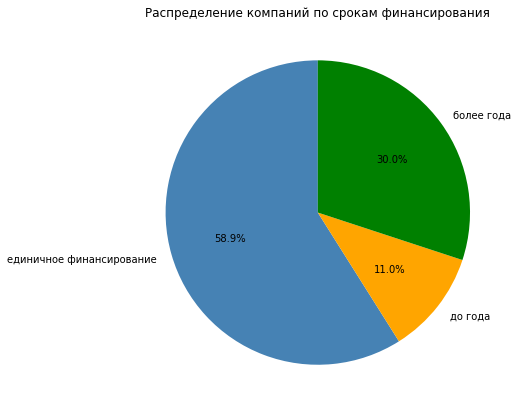

In [37]:
# Построим круговую диаграмму распределения компаний по группам
plt.figure(figsize=(7, 7))

plt.pie(
    company_share['share'],
    labels=company_share['funding_period_group'],
    autopct='%1.1f%%',
    startangle=90,
    colors=colors
)

plt.title('Распределение компаний по срокам финансирования')
plt.show()

Наибольшую долю составляют компании, получившие единичное финансирование - около 59% от общего числа стартапов. Это говорит о том, что большинство компаний привлекали инвестиции только один раз.

Около 30% компаний привлекали финансирование более одного года. Такие стартапы, вероятно, находились в стадии активного развития и проходили несколько инвестиционных раундов.

Наименьшую группу составляют компании, завершившие финансирование менее чем за год - около 11%. Это свидетельствует о том, что относительно небольшая часть стартапов проходит все раунды финансирования за короткий срок.

In [38]:
# Посчитаем долю инвестиций в каждой группе
investment_share = (
    investments_df
    .groupby('funding_period_group')['funding_total_usd']
    .sum()
    .reindex(group_order)
    .div(investments_df['funding_total_usd'].sum())
    .mul(100)
    .reset_index()
)

# Переименуем столбцы
investment_share.columns = ['funding_period_group', 'share']
investment_share

,funding_period_group,share
0,единичное финансирование,30.619851
1,до года,7.510528
2,более года,61.869622


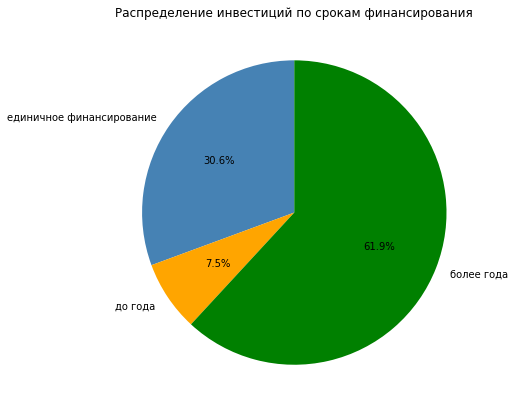

In [39]:
# Построим круговую диаграмму распределения инвестиций по группам
plt.figure(figsize=(7, 7))

plt.pie(
    investment_share['share'],
    labels=investment_share['funding_period_group'],
    autopct='%1.1f%%',
    startangle=90,
    colors=colors
)

plt.title('Распределение инвестиций по срокам финансирования')
plt.show()

Полученные результаты показывают, что большинство компаний (около 59%) привлекали финансирование только один раз. Однако на эту группу приходится лишь около 30,6% общего объёма инвестиций.

Наибольший объём привлечённых средств получили компании, финансирование которых продолжалось более года. Несмотря на то что они составляют около 30% всех стартапов, на их долю приходится почти 61,8% всех инвестиций. Это может свидетельствовать о том, что компании, проходящие несколько раундов финансирования в течение длительного времени, привлекают значительно больший объём капитала.

Наименьшая доля как по количеству компаний (около 11%), так и по объёму инвестиций (около 7,5%) приходится на стартапы, завершившие финансирование менее чем за год.

Таким образом, можно сделать предварительный вывод, что длительность финансирования связана с объёмом привлечённых инвестиций: компании, проходящие несколько раундов финансирования на протяжении более года, в среднем привлекают значительно больше средств, чем стартапы с единичным или краткосрочным финансированием.

### 2.2 Выделение средних и нишевых сегментов рынка

Компании указывают свой сегмент рынка в столбце `market`. Для дальнейшего анализа необходимо разделить сегменты на три группы: массовые, средние и нишевые.

Сначала рассчитаем, сколько компаний относится к каждому сегменту рынка.

In [40]:
# Посчитаем количество компаний в каждом сегменте рынка
market_counts = investments_df['market'].value_counts()

# Выведем результат
market_counts.head(10)

Software               4812
Biotechnology          3590
unknown                2503
Mobile                 2344
E-Commerce             1866
Curated Web            1693
Enterprise Software    1381
Health Care            1185
Clean Technology       1180
Games                  1117
Name: market, dtype: int64

Теперь разделим сегменты рынка на три категории в зависимости от количества компаний:

- массовые — более 120 компаний
- средние — от 35 до 120 компаний включительно
- нишевые — менее 35 компаний

In [41]:
# Посчитаем количество сегментов в каждой категории
market_group_counts = pd.Series({
    'массовые': (market_counts > 120).sum(),
    'средние': market_counts.between(35, 120).sum(),
    'нишевые': (market_counts < 35).sum()
})

market_group_counts

массовые     49
средние      57
нишевые     289
dtype: int64

Большинство рыночных сегментов относится к нишевым: в каждый из них входит менее 35 компаний. Средних сегментов заметно меньше, а массовые сегменты составляют наименьшую по количеству группу, однако объединяют значительную долю всех компаний.

In [42]:
# Создадим функцию для определения категории сегмента
def get_market_group(m):
    if market_counts[m] < 35:
        return 'niche'
    elif market_counts[m] <= 120:
        return 'mid'
    return m

In [43]:
# Заменим средние и нишевые сегменты на заглушки
investments_df['market'] = investments_df['market'].apply(get_market_group)

In [44]:
# Проверим количество компаний после объединения сегментов
investments_df['market'].value_counts().head(20)

Software               4812
mid                    3839
Biotechnology          3590
unknown                2503
Mobile                 2344
E-Commerce             1866
Curated Web            1693
Enterprise Software    1381
Health Care            1185
Clean Technology       1180
Games                  1117
Advertising            1107
Hardware + Software    1062
Social Media           1003
Health and Wellness     873
Education               844
niche                   830
Finance                 828
Analytics               667
Manufacturing           596
Name: market, dtype: int64

К массовым относятся 49 сегментов, к средним - 57, к нишевым - 289.

После объединения сегментов в столбце `market` появились две новые категории - `mid` и `niche`. Они объединяют все средние и нишевые сегменты соответственно, тогда как массовые сегменты сохранили свои исходные названия. Такая обработка позволяет сократить количество уникальных значений признака и упростить дальнейший анализ.

Теперь построим график распределения количества компаний в сегментах. На графике отметим границы, по которым сегменты делятся на нишевые и средние.

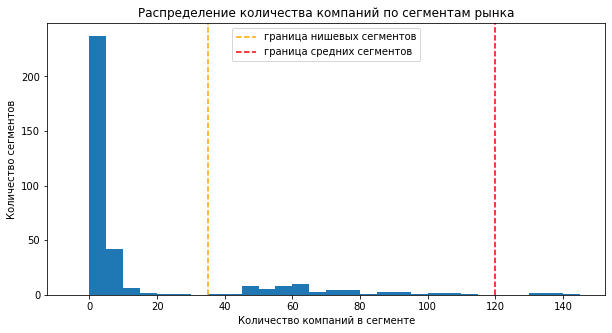

In [45]:
# Построим график распределения количества компаний по сегментам
plt.figure(figsize=(10, 5))

plt.hist(market_counts, bins=range(-5,150,5))

plt.axvline(35, color='orange', linestyle='--', label='граница нишевых сегментов')
plt.axvline(120, color='red', linestyle='--', label='граница средних сегментов')

plt.title('Распределение количества компаний по сегментам рынка')
plt.xlabel('Количество компаний в сегменте')
plt.ylabel('Количество сегментов')
plt.legend()
plt.show()

В ходе анализа сегменты рынка были разделены на три группы по количеству компаний: массовые, средние и нишевые. Массовые сегменты были оставлены в столбце `market` без изменений, а средние и нишевые объединены в категории `mid` и `niche`.

По графику видно, что большая часть исходных сегментов относится к нишевым: в них входит небольшое количество компаний. Средние сегменты встречаются реже, а массовых сегментов меньше всего, но именно они объединяют наибольшее количество стартапов.

После замены количество уникальных значений в столбце `market` сократилось. Это упростит дальнейший анализ: небольшие сегменты не будут рассматриваться по отдельности, а будут учитываться как две общие группы - `mid` и `niche`.

## Шаг 3. Работа с выбросами и анализ

### 3.1. Анализируем и помечаем выбросы в каждом из сегментов

Заказчика интересует типичный размер общего финансирования, который получали компании. Для начала визуально оценим распределение значений в столбце `funding_total_usd`, а затем опишем его с помощью основных статистик и определим, какое значение можно считать типичным.

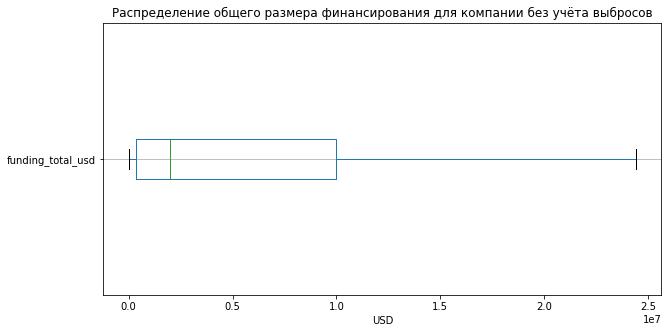

In [46]:
# Построим диаграмму размаха общего объёма финансирования без отображения выбросов
plt.figure(figsize=(10, 5))

investments_df.boxplot(
    column='funding_total_usd',
    showfliers=False,
    vert=False
)

plt.title('Распределение общего размера финансирования для компании без учёта выбросов')
plt.xlabel('USD')
plt.grid(axis='x')

plt.show()

По диаграмме размаха видно, что основная часть компаний получила сравнительно небольшие объёмы финансирования, тогда как отдельные компании привлекли существенно большие суммы. Чтобы понять, какое значение является типичным, посмотрим на основные статистики распределения.

In [47]:
# Посмотрим основные статистики общего финансирования в млн USD
investments_df['funding_total_usd'].describe().div(1000000).round(2)

count        0.04
mean        15.91
std        168.68
min          0.00
25%          0.35
50%          2.00
75%         10.00
max      30079.50
Name: funding_total_usd, dtype: float64

Описательная статистика показывает, что распределение общего объёма финансирования сильно смещено вправо. Средний объём финансирования составляет около 15,9 млн USD, тогда как медианный объём - около 2 млн USD. Такая разница говорит о том, что среднее значение сильно увеличивается из-за отдельных компаний с очень крупным финансированием.

Поэтому для оценки типичного размера средств корректнее ориентироваться на медиану. В рассматриваемом датасете типичный объём финансирования для одной компании составляет около 2 млн USD.

In [48]:
# Рассчитаем квартили
q1 = investments_df['funding_total_usd'].quantile(0.25)
q3 = investments_df['funding_total_usd'].quantile(0.75)

# Рассчитаем межквартильный размах
iqr = q3 - q1

# Рассчитаем границы типичных значений
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

print('Нижняя граница:', round(lower_bound))
print('Верхняя граница:', round(upper_bound))

Нижняя граница: -14125000
Верхняя граница: 24475000


Первый квартиль составляет 350 тыс. USD, медиана - 2 млн USD, а третий квартиль - 10 млн USD. Нижняя граница, рассчитанная методом IQR, получилась отрицательной. Поскольку объём финансирования не может быть меньше нуля, нижнюю границу типичного диапазона можно принять равной 0.

Верхняя граница типичных значений составляет около 24,5 млн USD. Значит, ориентировочный диапазон обычных значений лежит примерно от 0 до 24,5 млн USD, а значения выше этой границы можно считать выбивающимися при общей оценке распределения.

Для дальнейшего анализа аномалии будут определяться отдельно по каждому сегменту рынка, так как нормальный объём финансирования может отличаться в разных отраслях.

In [49]:
# Создадим столбец с отметкой аномального финансирования
investments_df['anomaly'] = False

# Получим список сегментов рынка
markets = investments_df['market'].unique()

In [50]:
# Найдём выбросы отдельно для каждого сегмента рынка
for market in markets:

    # Отберём компании одного сегмента
    market_df = investments_df[investments_df['market'] == market]

    # Рассчитаем квартили
    q1 = market_df['funding_total_usd'].quantile(0.25)
    q3 = market_df['funding_total_usd'].quantile(0.75)

    # Рассчитаем межквартильный размах
    iqr = q3 - q1

    # Рассчитаем верхнюю границу
    upper_bound = q3 + 1.5 * iqr

    # Отметим компании с аномальным финансированием
    investments_df.loc[
        (investments_df['market'] == market) & (investments_df['funding_total_usd'] > upper_bound), 
        'anomaly'] = True

Проверим, сколько компаний было отмечено как получившие аномальное финансирование.

In [51]:
# Посчитаем количество компаний с аномальным финансированием
investments_df['anomaly'].value_counts()

False    35661
True      5244
Name: anomaly, dtype: int64

Теперь определим, в каких сегментах рынка доля компаний с аномальным финансированием является наибольшей.

In [52]:
# Посчитаем долю компаний с аномальным финансированием по сегментам
outlier_share = (
    investments_df
    .groupby('market')['anomaly']
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

# Выведем топ-10 сегментов
outlier_share.head(10)

market
Real Estate        17.204301
Entertainment      16.666667
Consulting         16.618911
Search             16.494845
Cloud Computing    16.447368
Photography        16.176471
SaaS               16.176471
Technology         15.966387
Video              15.957447
niche              15.903614
Name: anomaly, dtype: float64

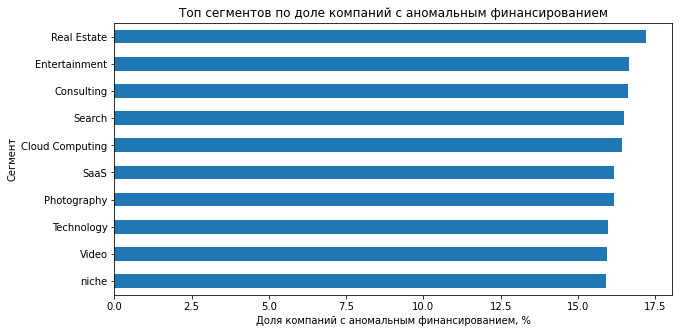

In [53]:
# Построим график сегментов с наибольшей долей аномального финансирования
plt.figure(figsize=(10, 5))

outlier_share.head(10).sort_values().plot(kind='barh')

plt.title('Топ сегментов по доле компаний с аномальным финансированием')
plt.xlabel('Доля компаний с аномальным финансированием, %')
plt.ylabel('Сегмент')

plt.show()

Поскольку размеры инвестиций существенно различаются между рынками, выбросы определялись отдельно для каждого сегмента. Такой подход позволяет учитывать особенности разных отраслей и избежать ситуации, когда типичные для одного сегмента значения ошибочно считаются аномальными для другого.

В результате было выявлено 5244 компании с аномальным объёмом финансирования. Наибольшая доля таких компаний наблюдается в сегментах `Real Estate`, `Entertainment`, `Consulting`, `Search` и `Cloud Computing`. В число лидеров также вошла категория `niche`, которая объединяет все нишевые сегменты рынка. Полученные результаты будут использованы на следующем этапе для исключения аномальных компаний из дальнейшего анализа.

### 3.2 Определяем границы рассматриваемого периода, отбрасываем аномалии

Сначала проверим, можно ли считать, что датасет содержит полные данные за 2014 год. Для этого посмотрим максимальные даты финансирования в столбцах `first_funding_at`, `mid_funding_at` и `last_funding_at`.

In [54]:
# Проверим максимальные даты в столбцах с финансированием
investments_df[['first_funding_at', 'mid_funding_at', 'last_funding_at']].max()

first_funding_at   2014-12-31
mid_funding_at     2014-12-31
last_funding_at    2014-12-31
dtype: datetime64[ns]

Дополнительно отдельно проверим максимальную дату последнего финансирования среди компаний, которые получали финансирование в 2014 году.

In [55]:
# Отберем компании, у которых последний раунд финансирования был в 2014 году
funding_2014 = investments_df[investments_df['last_funding_at'].dt.year == 2014]

# Проверим максимальную дату последнего финансирования в 2014 году
funding_2014['last_funding_at'].max()

Timestamp('2014-12-31 00:00:00')

In [56]:
# Посмотрим распределение последних раундов финансирования по месяцам 2014 года
funding_2014['last_funding_at'].dt.month.value_counts().sort_index()

1     1178
2      947
3     1072
4     1077
5     1036
6     1229
7     1254
8     1064
9     1134
10    1139
11     732
12      52
Name: last_funding_at, dtype: int64

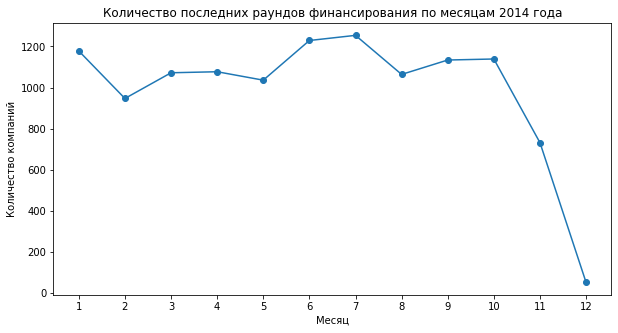

In [57]:
# Посчитаем количество компаний по месяцам последнего финансирования
funding_2014_by_month = (
    funding_2014['last_funding_at']
    .dt.month
    .value_counts()
    .sort_index()
)

# Построим линейный график количества компаний по месяцам
plt.figure(figsize=(10, 5))

plt.plot(
    funding_2014_by_month.index,
    funding_2014_by_month.values,
    marker='o'
)

# Добавим название графика и подписи осей
plt.title('Количество последних раундов финансирования по месяцам 2014 года')
plt.xlabel('Месяц')
plt.ylabel('Количество компаний')

# Отобразим на оси X все месяцы от 1 до 12
plt.xticks(range(1, 13))

plt.show()

На протяжении большей части 2014 года количество компаний, у которых был зафиксирован последний раунд финансирования, находилось примерно на одном уровне. Однако в ноябре показатель заметно снизился, а в декабре было зафиксировано только 52 компании, что значительно меньше значений предыдущих месяцев.

Несмотря на то что максимальная дата финансирования приходится на 31 декабря 2014 года и в данных присутствуют все месяцы, резкое сокращение количества наблюдений в конце года может свидетельствовать о неполноте данных. Поэтому результаты анализа за 2014 год следует интерпретировать с осторожностью.

Перед дальнейшим анализом исключим компании, которые ранее были отмечены как получившие аномальное финансирование.

In [58]:
# Удалим компании с аномальным финансированием
investments_df = investments_df.query('anomaly == False').copy()

# Проверим размер датафрейма после удаления аномалий
investments_df.shape

(35661, 43)

Теперь определим годы, в которые было зафиксировано не менее 50 раундов финансирования.

In [59]:
# Сохраним год средней даты финансирования
investments_df['funding_year'] = investments_df['mid_funding_at'].dt.year

# Посчитаем суммарное количество раундов финансирования по годам
rounds_by_year = (investments_df.groupby('funding_year')['funding_rounds'].sum().sort_index())

rounds_by_year

funding_year
1921        1.0
1960        2.0
1979        1.0
1982        3.0
1983        1.0
1984        2.0
1985        3.0
1987        2.0
1989        1.0
1990        1.0
1992        5.0
1993        1.0
1994        4.0
1995        9.0
1996        8.0
1997        5.0
1998       15.0
1999       43.0
2000      113.0
2001       66.0
2002       98.0
2003      125.0
2004      181.0
2005      948.0
2006     1849.0
2007     2842.0
2008     3663.0
2009     4617.0
2010     6136.0
2011     7578.0
2012     9705.0
2013    12880.0
2014     7122.0
Name: funding_rounds, dtype: float64

In [60]:
# Оставим годы, в которых было зафиксировано не менее 50 раундов
valid_years = rounds_by_year[rounds_by_year >= 50].index

valid_years

Int64Index([2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010,
            2011, 2012, 2013, 2014],
           dtype='int64', name='funding_year')

In [61]:
# Оставим компании, средняя дата финансирования которых относится к годам с достаточным количеством раундов
investments_df = investments_df[investments_df['funding_year'].isin(valid_years)].copy()

investments_df.shape

(35587, 44)

Проверка максимальных дат финансирования показала, что данные содержат информацию до 31 декабря 2014 года. Кроме того, финансирование зафиксировано во всех месяцах 2014 года, но число последних раундов в декабре (52) резко ниже, чем в остальные месяцы. Поэтому считать 2014 год полным нельзя.

После исключения компаний с аномальным объёмом финансирования было рассчитано суммарное количество раундов по годам. Для этого компании были сгруппированы по году средней даты финансирования, а значения funding_rounds просуммированы. В дальнейшем анализе оставлены только годы, в которых было зафиксировано не менее 50 раундов. Это позволяет исключить периоды с недостаточным объёмом наблюдений.

### 3.3. Анализ типов финансирования по объёму и популярности

Для анализа рассмотрим основные типы финансирования, представленные в датасете. Сначала определим, какие типы финансирования обеспечили наибольший общий объём привлечённых средств.

In [62]:
# Список столбцов с типами финансирования
funding_types = [
    'seed',
    'venture',
    'equity_crowdfunding',
    'undisclosed',
    'convertible_note',
    'debt_financing',
    'angel',
    'grant',
    'private_equity',
    'post_ipo_equity',
    'post_ipo_debt',
    'secondary_market',
    'product_crowdfunding'
]

In [63]:
# Посчитаем суммарный объём финансирования по каждому типу
funding_volume = (investments_df[funding_types].sum().sort_values(ascending=False))

funding_volume

venture                 1.290922e+11
seed                    9.431332e+09
debt_financing          8.178153e+09
private_equity          4.825109e+09
angel                   2.481264e+09
undisclosed             2.100352e+09
grant                   1.978849e+09
post_ipo_equity         1.946452e+09
convertible_note        5.660394e+08
post_ipo_debt           2.867183e+08
equity_crowdfunding     2.379606e+08
product_crowdfunding    1.860939e+08
secondary_market        4.528580e+07
dtype: float64

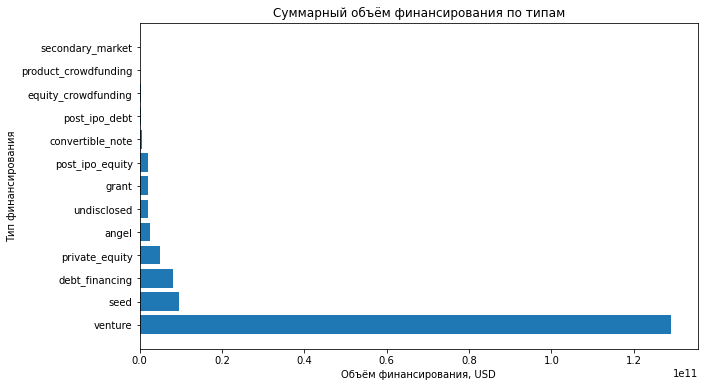

In [64]:
plt.figure(figsize=(10, 6))

plt.barh(
    funding_volume.index,
    funding_volume.values
)

plt.title('Суммарный объём финансирования по типам')
plt.xlabel('Объём финансирования, USD')
plt.ylabel('Тип финансирования')

plt.show()

Из графика видно, что наибольший суммарный объём привлечённых средств приходится на тип финансирования `venture`. Существенно уступают ему `seed` и `debt_financing`, тогда как остальные виды финансирования характеризуются значительно меньшими объёмами инвестиций.

Теперь определим, какие типы финансирования используются наиболее часто, то есть встречаются у наибольшего количества компаний.

In [65]:
# Посчитаем количество компаний, получивших каждый тип финансирования
funding_frequency = (
    (investments_df[funding_types] > 0)
    .sum()
    .sort_values(ascending=False)
)

funding_frequency

venture                 18820
seed                    13375
debt_financing           3265
angel                    2937
grant                    1003
undisclosed               813
private_equity            633
convertible_note          521
equity_crowdfunding       515
product_crowdfunding      204
post_ipo_equity           164
post_ipo_debt              27
secondary_market            7
dtype: int64

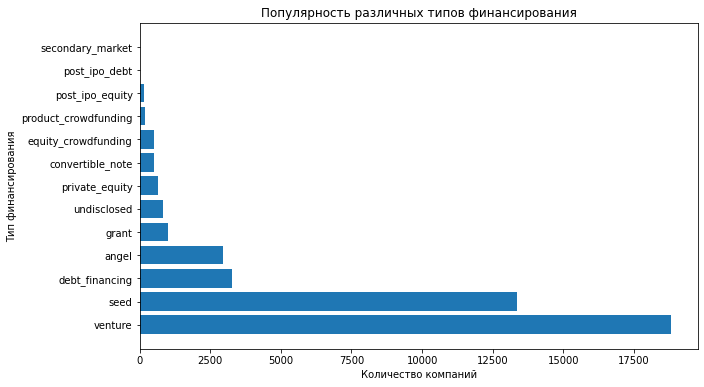

In [66]:
plt.figure(figsize=(10, 6))

plt.barh(
    funding_frequency.index,
    funding_frequency.values
)

plt.title('Популярность различных типов финансирования')
plt.xlabel('Количество компаний')
plt.ylabel('Тип финансирования')

plt.show()

По количеству компаний также лидирует `venture`, за ним следуют `seed` и `debt_financing`. Большинство остальных типов финансирования встречаются значительно реже.

Сравним полученные результаты с данными дополнительного датасета и определим, какие типы финансирования обеспечили наибольший суммарный объём возвратов за весь рассматриваемый период.

In [67]:
# Посчитаем суммарные возвраты по каждому типу финансирования
returns_sum = (
    returns_df[funding_types]
    .sum()
    .sort_values(ascending=False)
)

returns_sum

venture                 40578.62
debt_financing           4734.85
private_equity           3587.33
seed                     2382.24
angel                    1509.23
post_ipo_equity          1104.96
undisclosed               730.88
post_ipo_debt              91.03
convertible_note           34.79
secondary_market            5.20
equity_crowdfunding         3.83
product_crowdfunding        1.86
grant                       0.00
dtype: float64

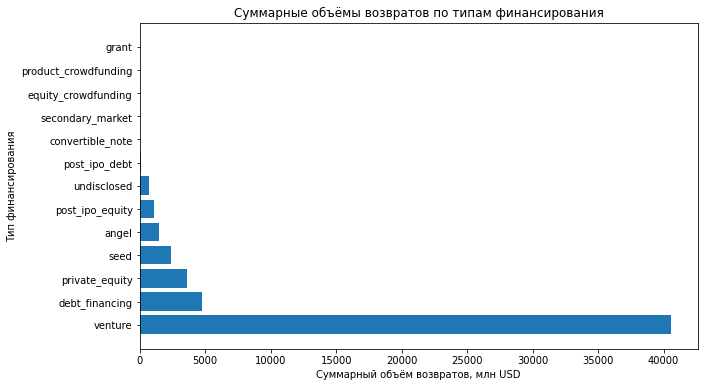

In [68]:
plt.figure(figsize=(10, 6))

plt.barh(
    returns_sum.index,
    returns_sum.values
)

plt.title('Суммарные объёмы возвратов по типам финансирования')
plt.xlabel('Суммарный объём возвратов, млн USD')
plt.ylabel('Тип финансирования')

plt.show()

Анализ показал, что лидером как по общему объёму привлечённых средств, так и по количеству компаний является тип финансирования `venture`. Значительно уступают ему `seed` и `debt_financing`, которые также широко распространены и обеспечивают крупные объёмы инвестиций.

Сравнение первых двух графиков показывает, что популярность типа финансирования не всегда соответствует объёму привлечённых средств. Например, `angel` и `grant` используются относительно часто, однако общий объём инвестиций по ним значительно ниже. Напротив, `private_equity` применяется существенно реже, чем `seed`, но обеспечивает значительно больший объём финансирования на одну компанию. Аналогичная ситуация наблюдается и для `post_ipo_equity`, который встречается крайне редко, однако сопровождается крупными инвестициями.

Анализ дополнительного датасета с возвратами показывает аналогичную закономерность. Наибольший объём возвратов приходится на `venture`, затем следуют `debt_financing`, `private_equity` и `seed`. Для большинства остальных типов финансирования объёмы возвратов значительно ниже, а по типу `grant` возвраты отсутствуют.

Таким образом, `venture` является основным источником привлечения капитала и одновременно лидирует по объёму возвратов. При этом отдельные виды финансирования, например `private_equity`, несмотря на сравнительно редкое использование, позволяют привлекать крупные объёмы инвестиций, тогда как `angel` и `grant` применяются чаще, но обычно сопровождаются значительно меньшими суммами финансирования.

## Шаг 4. Анализ динамики

### 4.1 Динамика предоставления финансирования по годам

Для анализа динамики рассчитаем средний объём одного раунда финансирования для каждой компании. Для этого разделим общий объём привлечённых средств `funding_total_usd` на количество раундов `funding_rounds`.

Дальнейший анализ будем выполнять на данных, которые остались после удаления аномалий и фильтрации по годам с достаточным количеством наблюдений.

In [69]:
# Рассчитаем средний объём одного раунда финансирования для каждой компании
investments_df['funding_per_round'] = (
    investments_df['funding_total_usd'] / investments_df['funding_rounds']
)

# Проверим результат
investments_df[['funding_total_usd', 'funding_rounds', 'funding_per_round']].head()

,funding_total_usd,funding_rounds,funding_per_round
1,2000000.0,1.0,2.000000e+06
2,9000000.0,1.0,9.000000e+06
3,7700000.0,3.0,2.566667e+06
4,540000.0,1.0,5.400000e+05
7,8700000.0,1.0,8.700000e+06


Теперь посмотрим, как менялся типичный размер одного раунда финансирования по годам. В качестве типичного значения используем медиану, так как она менее чувствительна к выбросам, чем среднее.

In [70]:
# Рассчитаем медианный размер одного раунда финансирования по годам
funding_per_round_by_year = (investments_df.groupby('funding_year')['funding_per_round'].median())

# Выведем результат
funding_per_round_by_year

funding_year
2000    2.250000e+06
2001    1.570886e+06
2002    3.225000e+06
2003    1.500000e+06
2004    3.000000e+06
2005    4.500000e+06
2006    3.900000e+06
2007    2.879167e+06
2008    2.170744e+06
2009    1.498475e+06
2010    1.250000e+06
2011    8.676850e+05
2012    6.860000e+05
2013    5.590000e+05
2014    5.606250e+05
Name: funding_per_round, dtype: float64

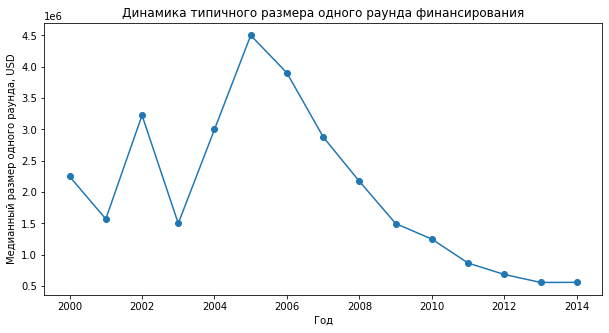

In [71]:
# Построим график динамики медианного размера одного раунда финансирования
plt.figure(figsize=(10, 5))

plt.plot(
    funding_per_round_by_year.index,
    funding_per_round_by_year.values,
    marker='o'
)

plt.title('Динамика типичного размера одного раунда финансирования')
plt.xlabel('Год')
plt.ylabel('Медианный размер одного раунда, USD')

plt.show()

Теперь оценим активность инвестиционного рынка по годам. Для этого рассчитаем общее количество раундов финансирования за каждый год.

In [72]:
# Рассчитаем общее количество раундов финансирования по годам
rounds_sum_by_year = (investments_df.groupby('funding_year')['funding_rounds'].sum())

# Выведем результат
rounds_sum_by_year

funding_year
2000      113.0
2001       66.0
2002       98.0
2003      125.0
2004      181.0
2005      948.0
2006     1849.0
2007     2842.0
2008     3663.0
2009     4617.0
2010     6136.0
2011     7578.0
2012     9705.0
2013    12880.0
2014     7122.0
Name: funding_rounds, dtype: float64

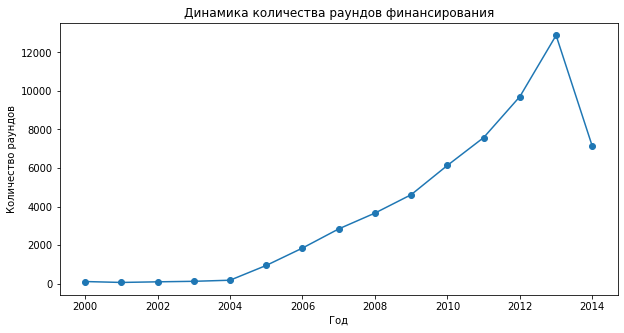

In [73]:
# Построим график динамики количества раундов финансирования
plt.figure(figsize=(10, 5))

plt.plot(
    rounds_sum_by_year.index,
    rounds_sum_by_year.values,
    marker='o'
)

plt.title('Динамика количества раундов финансирования')
plt.xlabel('Год')
plt.ylabel('Количество раундов')

plt.show()

In [74]:
# Найдём год с максимальным типичным размером одного раунда
max_funding_year = funding_per_round_by_year.idxmax()
max_funding_value = funding_per_round_by_year.max()

print('Год с максимальным типичным размером одного раунда:', max_funding_year)
print('Максимальный медианный размер одного раунда:', round(max_funding_value, 2))

Год с максимальным типичным размером одного раунда: 2005
Максимальный медианный размер одного раунда: 4500000.0


In [75]:
# Посмотрим значения за 2013 и 2014 годы
dynamic_2013_2014 = pd.DataFrame({
    'median_funding_per_round': funding_per_round_by_year,
    'rounds_count': rounds_sum_by_year
}).loc[[2013, 2014]]

dynamic_2013_2014.round(2)

,median_funding_per_round,rounds_count
funding_year,,
2013,559000.0,12880.0
2014,560625.0,7122.0


Максимальный типичный размер одного раунда финансирования наблюдался в 2005 году и составлял около 4,5 млн USD. После этого медианный размер раунда постепенно снижался, что может быть связано с увеличением числа сравнительно небольших инвестиционных сделок.

Количество раундов росло вплоть до 2013 года. В 2014 году в данных наблюдается снижение количества зафиксированных раундов с 12 880 до 7 122. При этом медианный размер одного раунда практически не изменился: он увеличился с 559 тыс. USD в 2013 году до примерно 561 тыс. USD в 2014 году.

Следовательно, по имеющимся данным уменьшилось количество зафиксированных сделок, а не их типичный размер. Однако это снижение нельзя однозначно считать реальным падением инвестиционной активности, поскольку данные за конец 2014 года, вероятно, представлены не полностью.

### 4.2 Динамика размера общего финансирования по массовым сегментам рынка для растущих в 2014 году сегментов

Теперь проанализируем, как менялся суммарный объём финансирования по массовым сегментам рынка. Средние и нишевые сегменты, объединённые в категории `mid` и `niche`, исключим из анализа, так как по заданию нужно рассматривать только массовые сегменты.

In [76]:
# Оставим только реальные массовые сегменты. Исключим средние, нишевые и неизвестные рынки
mass_market_df = investments_df[~investments_df['market'].isin(['mid', 'niche', 'unknown'])].copy()

# Проверим результат
mass_market_df['market'].value_counts().head()

Software         4223
Biotechnology    3207
Mobile           2028
E-Commerce       1593
Curated Web      1486
Name: market, dtype: int64

Для анализа динамики были оставлены только реальные массовые сегменты рынка. Средние и нишевые сегменты исключены, так как по условию задания они объединены в категории `mid` и `niche` и не должны рассматриваться отдельно. Категория `unknown` также исключена, поскольку она обозначает отсутствие информации о рынке и не является содержательным рыночным сегментом.

Составим сводную таблицу с суммарным объёмом финансирования по годам и сегментам рынка.

In [77]:
# Создадим сводную таблицу по годам и сегментам рынка
market_year_pivot = mass_market_df.pivot_table(
    index='funding_year',
    columns='market',
    values='funding_total_usd',
    aggfunc='sum'
).fillna(0)

# Проверим результат
market_year_pivot.head()

market,Advertising,Analytics,Apps,Automotive,Big Data,Biotechnology,Clean Technology,Cloud Computing,Consulting,Curated Web,...,Semiconductors,Social Media,Social Network Media,Software,Sports,Startups,Technology,Travel,Video,Web Hosting
funding_year,,,,,,,,,,,,,,,,,,,,,
2000,14470000.0,14822803.0,0.0,0.0,0.0,0.0,0.0,11500000.0,4500000.0,1000000.0,...,0.0,0.0,0.0,31732640.0,0.0,0.0,0.0,50230.0,0.0,95343090.0
2001,8778321.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,305000.0,...,101727992.0,650000.0,0.0,27811352.0,0.0,0.0,22160000.0,0.0,0.0,15000000.0
2002,24500000.0,7500000.0,0.0,0.0,0.0,0.0,34390435.0,0.0,0.0,4650000.0,...,0.0,0.0,0.0,101026395.0,200000.0,0.0,11000000.0,0.0,0.0,0.0
2003,10500000.0,3840000.0,0.0,4530000.0,0.0,85531178.0,50352939.0,0.0,0.0,2550000.0,...,28000000.0,5000.0,0.0,66086037.0,0.0,0.0,0.0,0.0,5000000.0,0.0
2004,6000000.0,3000000.0,0.0,0.0,0.0,97184859.0,50427954.0,0.0,0.0,27050000.0,...,88782797.0,6850000.0,0.0,140823795.0,0.0,0.0,1750000.0,10230000.0,14704000.0,27000000.0


Сводная таблица показывает суммарный объём финансирования по каждому массовому сегменту и году. Она нужна для того, чтобы сравнить объём финансирования в 2013 и 2014 годах и отобрать только те сегменты, которые показали рост к концу рассматриваемого периода.

Теперь определим сегменты, в которых суммарный объём финансирования в 2014 году был выше, чем в 2013 году.

In [78]:
# Отберем сегменты, которые выросли в 2014 году по сравнению с 2013 годом
growing_markets = market_year_pivot.loc[2014][market_year_pivot.loc[2014] > market_year_pivot.loc[2013]].index

# Выведем растущие сегменты
growing_markets

Index(['Apps', 'Big Data', 'Design', 'Internet', 'Manufacturing', 'Medical',
       'Real Estate', 'SaaS', 'Startups', 'Technology'],
      dtype='object', name='market')

В список растущих попали только те массовые сегменты, у которых суммарный объём финансирования в 2014 году оказался выше, чем в 2013 году. Дальше будем анализировать динамику только этих сегментов.

In [79]:
# Рассчитаем абсолютное изменение финансирования
growth_abs = (market_year_pivot.loc[2014] - market_year_pivot.loc[2013])

# Рассчитаем относительное изменение. Нулевые значения заменим на пропуски, чтобы избежать деления на ноль
growth_percent = (growth_abs / market_year_pivot.loc[2013].replace(0, np.nan) * 100)

growth_table = pd.DataFrame({
    'funding_2013': market_year_pivot.loc[2013],
    'funding_2014': market_year_pivot.loc[2014],
    'absolute_growth': growth_abs,
    'growth_percent': growth_percent
})

growth_table = (growth_table.query('absolute_growth > 0').sort_values('absolute_growth', ascending=False))

growth_table.head(10)

,funding_2013,funding_2014,absolute_growth,growth_percent
market,,,,
Medical,64469424.0,175236064.0,110766640.0,171.812672
Technology,120873887.0,202018937.0,81145050.0,67.131994
Internet,69732096.0,117830756.0,48098660.0,68.976358
Apps,28868621.0,66237730.0,37369109.0,129.445424
Startups,18080552.0,41501837.0,23421285.0,129.538551
Real Estate,92207655.0,115567364.0,23359709.0,25.333807
Manufacturing,393936634.0,416332314.0,22395680.0,5.685097
SaaS,79576613.0,92807752.0,13231139.0,16.626919
Design,60958835.0,68988516.0,8029681.0,13.172301


Расчёт показал, что в 2014 году по сравнению с 2013 выросли 10 массовых сегментов. По абсолютному приросту финансирования лидируют `Medical` (+110,8 млн), `Technology` (+81,1 млн) и `Internet` (+48,1 млн). По относительному приросту заметнее всего выделяются `Medical` (+172%), `Startups` (+130%) и `Apps` (+129%). Некоторые сегменты выросли лишь незначительно - например, `Big Data` прибавил менее 1%.

Для дальнейшей визуализации оставим в сводной таблице все растущие сегменты и посмотрим на их динамику по годам.

In [80]:
# Оставим в сводной таблице только растущие сегменты
growing_market_pivot = market_year_pivot[growing_markets]

# Проверим результат
growing_market_pivot.head()

market,Apps,Big Data,Design,Internet,Manufacturing,Medical,Real Estate,SaaS,Startups,Technology
funding_year,,,,,,,,,,
2000,0.0,0.0,0.0,10000000.0,56659310.0,24000000.0,2500000.0,0.0,0.0,0.0
2001,0.0,0.0,0.0,0.0,2368582.0,0.0,0.0,0.0,0.0,22160000.0
2002,0.0,0.0,0.0,1100000.0,0.0,0.0,5275000.0,2000000.0,0.0,11000000.0
2003,0.0,0.0,0.0,0.0,4269608.0,0.0,6292200.0,0.0,0.0,0.0
2004,0.0,0.0,0.0,10500000.0,3000000.0,0.0,0.0,0.0,0.0,1750000.0


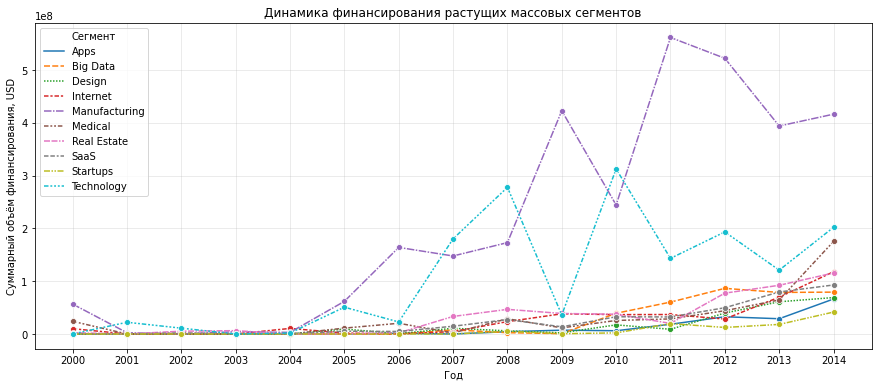

In [81]:
# Построим график динамики финансирования по растущим массовым сегментам
plt.figure(figsize=(15, 6))

sns.lineplot(data=growing_market_pivot, marker='o')

plt.xticks(growing_market_pivot.index)

plt.title('Динамика финансирования растущих массовых сегментов')
plt.xlabel('Год')
plt.ylabel('Суммарный объём финансирования, USD')
plt.legend(title='Сегмент')
plt.grid(alpha=0.3)

plt.show()

На графике видно, что растущие массовые сегменты развивались неравномерно. По абсолютному приросту финансирования между 2013 и 2014 годами сильнее всего выделяются `Medical`, `Technology` и `Internet`. Эти сегменты не только выросли к концу рассматриваемого периода, но и имеют заметный объём привлечённого финансирования.

Сегменты `Apps` и `Startups` также показали высокий относительный прирост, однако их общий объём финансирования ниже, чем у лидеров по абсолютному росту. `Manufacturing` остаётся крупным по объёму сегментом, но его относительный рост в 2014 году был умеренным.

Таким образом, наиболее убедительно выглядят сегменты `Medical`, `Technology` и `Internet`: они сочетают положительную динамику с достаточно крупным объёмом финансирования. При этом выводы за 2014 год следует интерпретировать осторожно, так как ранее было выявлено, что данные за конец года могут быть неполными.

### 4.3 Годовая динамика доли возвращённых средств по типам финансирования

Заказчика интересует, какая часть вложенных средств возвращается обратно инвесторам. Для этого рассчитаем долю возвратов: сумму возвращённых средств разделим на суммарный объём предоставленного финансирования по каждому году и типу финансирования.

В анализе рассмотрим типы финансирования `venture`, `debt_financing`, `private_equity`, `seed` и `angel`.

In [82]:
# Сохраним типы финансирования для анализа
return_types = ['venture', 'debt_financing', 'private_equity', 'seed', 'angel']

# Рассчитаем суммарный объём финансирования по годам
funding_by_year_type = (investments_df.groupby('funding_year')[return_types].sum())

# Рассчитаем долю возвращённых средств в долларах
returns_share = (returns_df[return_types] * 1000000 / (funding_by_year_type + 1e-60))

# Заменим значения на пропуски в тех случаях, когда финансирование определённого типа в году было равно нулю
for column in return_types:
    zero_funding_years = funding_by_year_type[
        funding_by_year_type[column] == 0
    ].index
    returns_share.loc[zero_funding_years, column] = np.nan

# Проверим результат
returns_share.head()

,venture,debt_financing,private_equity,seed,angel
year,,,,,
2000,0.168922,0.618571,NaN,0.996471,0.266956
2001,0.107991,0.770258,NaN,1.079592,1.180000
2002,0.682282,0.223388,0.201333,0.629707,1.136667
2003,0.628260,1.038095,NaN,0.505276,0.605720
2004,0.837009,0.439698,NaN,0.548476,0.833504


При расчёте доли возвратов в отдельных годах появились чрезвычайно большие значения. Они возникли в тех случаях, когда объём предоставленного финансирования определённого типа был равен нулю, а деление выполнялось на добавленное к знаменателю небольшое число `1e-60`.

Такие значения нельзя содержательно интерпретировать, поэтому для соответствующих годов и типов финансирования они были заменены на пропуски.

In [83]:
# Заменим слишком большие значения на пропуски
for column in return_types:
    returns_share.loc[returns_share[column] > 1, column] = np.nan

# Проверим результат
returns_share.head()

,venture,debt_financing,private_equity,seed,angel
year,,,,,
2000,0.168922,0.618571,NaN,0.996471,0.266956
2001,0.107991,0.770258,NaN,NaN,NaN
2002,0.682282,0.223388,0.201333,0.629707,NaN
2003,0.628260,NaN,NaN,0.505276,0.605720
2004,0.837009,0.439698,NaN,0.548476,0.833504


После обработки нулевых знаменателей в данных остались значения доли возврата выше 1. В рамках выбранной метрики это означает, что сумма возвратов за год превышает объём предоставленного финансирования того же типа в этом же году. Такие значения могут возникать из-за того, что возвраты конкретного года не обязательно относятся к инвестициям, сделанным в тот же год. Однако по условию задания слишком большие значения нужно заменить на пропуски, поэтому значения выше 1 были обработаны как аномальные.

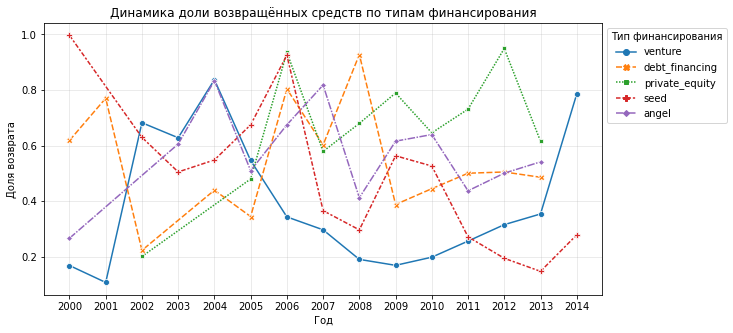

In [84]:
# Построим график динамики доли возвращённых средств
plt.figure(figsize=(10, 5))

sns.lineplot(data=returns_share, markers=True)

plt.xticks(returns_share.index)

plt.title('Динамика доли возвращённых средств по типам финансирования')
plt.xlabel('Год')
plt.ylabel('Доля возврата')
plt.legend(title='Тип финансирования', bbox_to_anchor=(1, 1), loc='upper left')
plt.grid(alpha=0.3)

plt.show()

На графике видно, что динамика доли возвращённых средств заметно различается между типами финансирования. У `private_equity`, `debt_financing`, `seed` и `angel` в отдельные годы наблюдаются высокие значения, однако их динамика менее равномерна: показатели заметно колеблются, а часть значений была заменена на пропуски как аномальная.

Тип `venture` демонстрирует более устойчивую динамику по сравнению с остальными типами финансирования. Его значения не всегда являются максимальными, однако к концу рассматриваемого периода показатель заметно растёт, а сама линия выглядит более последовательной.

Следует учитывать, что возвраты, зафиксированные в определённом году, не обязательно относятся к финансированию, предоставленному в том же году. Поэтому рассчитанная доля возврата является упрощённой нормированной метрикой, а не прямой оценкой доходности конкретных инвестиций.

Таким образом, наиболее устойчивый рост нормированной доли возвратов наблюдается у `venture`. Для остальных типов финансирования динамика менее стабильна и сильнее зависит от отдельных лет.


## Шаг 5. Итоговый вывод и рекомендации

### Рекомендации заказчику

Если представить, что на календаре 2015 год, наиболее перспективным направлением для инвестирования можно считать сегмент `Medical`.

Этот сегмент относится к массовым рынкам и показал наиболее сильный рост суммарного объёма финансирования в 2014 году по сравнению с 2013 годом. Абсолютный прирост составил около 110,8 млн USD, а относительный - около 171,8%. Это делает `Medical` одним из наиболее заметных растущих сегментов в конце рассматриваемого периода.

Дополнительно можно рассматривать сегменты `Technology` и `Internet`. Они также показали заметный рост финансирования в 2014 году и отличаются достаточно крупным объёмом привлечённых средств. Однако в качестве основной рекомендации выбран именно `Medical`, так как он сочетает самый высокий абсолютный прирост с сильной относительной динамикой. Эту рекомендацию следует рассматривать как ставку на быстрорастущий, но менее ёмкий сегмент, тогда как `Technology` и `Internet` дают более умеренный рост при более крупном объёме рынка.

В качестве наиболее уместного типа финансирования рекомендуется `venture`. Этот тип финансирования лидирует по суммарному объёму привлечённых средств и по количеству компаний, то есть является наиболее распространённым и масштабным инструментом на рынке стартапов. Кроме того, по дополнительному датасету именно `venture` показывает наибольший абсолютный объём возвратов.

При этом основной аргумент в пользу `venture` связан не только с масштабом. Анализ нормированной доли возвратов показал, что у `venture` наблюдается наиболее устойчивый рост показателя к концу рассматриваемого периода. У других типов финансирования в отдельные годы встречаются высокие значения, но их динамика менее равномерна и чаще сопровождается резкими колебаниями.

Таким образом, наиболее рациональная рекомендация для заказчика - рассмотреть инвестиции в сегмент `Medical` с использованием венчурного финансирования. В качестве дополнительных направлений можно учитывать `Technology` и `Internet`, но с осторожной интерпретацией результатов за 2014 год из-за возможной неполноты данных в конце года.

---

### Итоги проекта

В ходе проекта были исследованы данные о финансировании стартапов на основе информации из базы Crunchbase. Работа включала загрузку двух датасетов: основного датасета с информацией о компаниях и финансировании, а также дополнительного датасета с данными о возвратах средств по типам финансирования.

На этапе предобработки были проверены структура данных, названия столбцов, типы данных и пропущенные значения. В столбце `funding_total_usd` были удалены разделители разрядов, значения с отсутствующей суммой финансирования были заменены на пропуски, после чего столбец был приведён к числовому типу. Столбцы с датами были преобразованы в формат `datetime`, а в дополнительном датасете столбец `year` был сделан индексом.

Также были обработаны пропуски и дубликаты. Текстовые пропуски были заполнены заглушкой `unknown`, строки без информации об общем объёме финансирования были удалены, а пропуски в `mid_funding_at` были заполнены серединой интервала между первым и последним раундом финансирования. После предобработки в данных осталось достаточно наблюдений для дальнейшего анализа.

На этапе инжиниринга признаков компании были разделены на группы по срокам финансирования: с единичным финансированием, со сроком финансирования до года и со сроком финансирования более года. Анализ показал, что большинство компаний получали финансирование один раз, однако наибольшая доля инвестиций приходится на компании, которые привлекали финансирование более года.

Затем были выделены массовые, средние и нишевые сегменты рынка. Массовые сегменты были сохранены под исходными названиями, а средние и нишевые объединены в категории `mid` и `niche`. Категория `unknown` рассматривалась отдельно как техническая заглушка и не использовалась для содержательных отраслевых рекомендаций.

Далее был проведён анализ выбросов. Типичный объём общего финансирования для одной компании оказался в диапазоне примерно от 0 до 24,5 млн USD. Аномальные значения были определены методом межквартильного размаха отдельно для каждого сегмента рынка, чтобы учитывать различия между отраслями. После этого компании с аномальным объёмом финансирования были исключены из дальнейшего анализа.

При проверке полноты данных за 2014 год было выявлено, что максимальная дата финансирования приходится на 31 декабря 2014 года, однако количество наблюдений в декабре резко ниже, чем в предыдущие месяцы. Поэтому данные за 2014 год нельзя считать полностью представленными, а выводы по этому году требуют осторожной интерпретации.

В анализе типов финансирования было установлено, что `venture` лидирует по суммарному объёму привлечённых средств, по количеству компаний и по абсолютному объёму возвратов. `Seed` также широко используется, но уступает `venture` по объёму. `Private_equity`, напротив, встречается реже, однако связано с крупными суммами финансирования.

В динамике по годам максимальный типичный размер одного раунда финансирования наблюдался в 2005 году и составлял около 4,5 млн USD. После этого медианный размер раунда постепенно снижался. Количество раундов росло до 2013 года, а в 2014 году в данных наблюдается снижение числа зафиксированных раундов. Однако это снижение нельзя однозначно считать реальным падением активности рынка, так как данные за конец 2014 года могут быть неполными. При этом типичный размер одного раунда в 2014 году практически не изменился по сравнению с 2013 годом.

Анализ массовых сегментов рынка показал, что среди сегментов, выросших в 2014 году, наиболее заметно выделяются `Medical`, `Technology` и `Internet`. Сегмент `Medical` показал самый сильный абсолютный и относительный прирост финансирования, поэтому был выбран как основная рекомендация для инвестирования.

Дополнительно была рассчитана нормированная доля возвратов по основным типам финансирования. Расчёт показал, что наиболее устойчивый рост этого показателя наблюдается у `venture`. При этом метрику нужно интерпретировать осторожно, поскольку возвраты конкретного года не обязательно относятся к финансированию, предоставленному в том же году.

В целом результаты исследования в основном согласуются между собой: быстрорастущие массовые сегменты продолжают привлекать капитал, а `venture` остаётся наиболее масштабным и устойчивым типом финансирования. Основное сомнение связано с неполнотой данных за конец 2014 года, поэтому рекомендации следует рассматривать как аналитически обоснованные, но требующие дополнительной проверки на более полном наборе данных.